\# 01 - Tải và Tiền xử lý Dữ liệu Oxford-IIIT Pet Dataset (Phần Ảnh Mèo) \*\*Mục tiêu:\*\* 1\. Tải tự động bộ dữ liệu Oxford-IIIT Pet Dataset (ảnh + file chú thích annotations). 2\. Lọc riêng các giống mèo sử dụng \`annotations/list.txt\` (\`Species == 1\`). 3\. Chia tập dữ liệu theo tỷ lệ \*\*70% Train - 15% Validation - 15% Test\*\* (Stratified Split). 4\. Tổ chức thư mục dữ liệu chuẩn dạng ImageFolder cho TensorFlow/PyTorch.


In [7]:
import os
import shutil
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from pathlib import Path


# Chọn đường dẫn gốc theo nơi notebook đang mở
if Path("../data/raw/dataset-iiit-pet-master/annotations/list.txt").exists():
    RAW_DATA_DIR = "../data/raw/dataset-iiit-pet-master"
    PROCESSED_DATA_DIR = "../data/processed/cats"
elif Path("data/raw/dataset-iiit-pet-master/annotations/list.txt").exists():
    RAW_DATA_DIR = "data/raw/dataset-iiit-pet-master"
    PROCESSED_DATA_DIR = "data/processed/cats"
else:
    # Fallback tuyệt đối
    RAW_DATA_DIR = r"d:\Code\GitHub\cnn-cat-breed-classification\data\raw\dataset-iiit-pet-master"
    PROCESSED_DATA_DIR = r"d:\Code\GitHub\cnn-cat-breed-classification\data\processed\cats"

IMAGES_DIR = os.path.join(RAW_DATA_DIR, "images")
ANNOTATIONS_DIR = os.path.join(RAW_DATA_DIR, "annotations")
LIST_FILE = os.path.join(ANNOTATIONS_DIR, "list.txt")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

print("RAW_DATA_DIR =", RAW_DATA_DIR)
print("PROCESSED_DATA_DIR =", PROCESSED_DATA_DIR)

print("Đã khai báo xong thư viện và cấu hình đường dẫn!")


RAW_DATA_DIR = ../data/raw/dataset-iiit-pet-master
PROCESSED_DATA_DIR = ../data/processed/cats
Đã khai báo xong thư viện và cấu hình đường dẫn!


In [8]:
# Đọc file list.txt (bỏ dòng comment bắt đầu bằng '#')
df = pd.read_csv(
    LIST_FILE,
    sep=" ",
    comment="#",
    header=None,
    names=["Image", "Class_ID", "Species", "Breed_ID"],
)

# Filter: Species == 1 đại diện cho Mèo (2 là Chó)
cat_df = df[df["Species"] == 1].copy()

# Trích xuất tên giống mèo từ tên file ảnh (ví dụ: 'Abyssinian_100' -&gt; 'Abyssinian')
def get_breed_name(image_name):
  parts = image_name.split("_")
  return "_".join(parts[:-1])

cat_df["Breed_Name"] = cat_df["Image"].apply(get_breed_name)

print(f"Tổng số ảnh mèo lọc được: {len(cat_df)}")
print(f"Số lượng giống mèo: {cat_df['Breed_Name'].nunique()}")
print("\nThống kê số ảnh theo từng giống mèo:")
print(cat_df["Breed_Name"].value_counts())


Tổng số ảnh mèo lọc được: 2371
Số lượng giống mèo: 12

Thống kê số ảnh theo từng giống mèo:
Breed_Name
Bengal               200
Birman               200
British_Shorthair    200
Maine_Coon           200
Persian              200
Ragdoll              200
Russian_Blue         200
Sphynx               200
Siamese              199
Abyssinian           198
Egyptian_Mau         190
Bombay               184
Name: count, dtype: int64


In [9]:
# Bước 1: Chia 70% Train, 30% cho Temp (để tiếp tục chia Val &amp; Test)
train_df, temp_df = train_test_split(
    cat_df,
    test_size=0.30,
    random_state=42,
    stratify=cat_df["Breed_Name"],  # Đảm bảo tỷ lệ các lớp đồng đều
)

# Bước 2: Chia 30% Temp thành 15% Val và 15% Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["Breed_Name"],
)

print(f"Tập Train: {len(train_df)} ảnh ({len(train_df)/len(cat_df):.1%})")
print(f"Tập Val:   {len(val_df)} ảnh ({len(val_df)/len(cat_df):.1%})")
print(f"Tập Test:  {len(test_df)} ảnh ({len(test_df)/len(cat_df):.1%})")


Tập Train: 1659 ảnh (70.0%)
Tập Val:   356 ảnh (15.0%)
Tập Test:  356 ảnh (15.0%)


In [10]:
def copy_images_to_folders(df, split_name):
  copied = 0
  for _, row in df.iterrows():
    breed = row["Breed_Name"]
    img_name = f"{row['Image']}.jpg"

    src_path = os.path.join(IMAGES_DIR, img_name)
    dst_dir = os.path.join(PROCESSED_DATA_DIR, split_name, breed)
    os.makedirs(dst_dir, exist_ok=True)

    dst_path = os.path.join(dst_dir, img_name)

    if os.path.exists(src_path):
      shutil.copy(src_path, dst_path)
      copied += 1

  print(f"✓ Đã copy {copied} ảnh vào 'data/processed/cats/{split_name}/'")

# Thực hiện lưu ảnh vào 3 tập
copy_images_to_folders(train_df, "train")
copy_images_to_folders(val_df, "val")
copy_images_to_folders(test_df, "test")


✓ Đã copy 1659 ảnh vào 'data/processed/cats/train/'
✓ Đã copy 356 ảnh vào 'data/processed/cats/val/'
✓ Đã copy 356 ảnh vào 'data/processed/cats/test/'


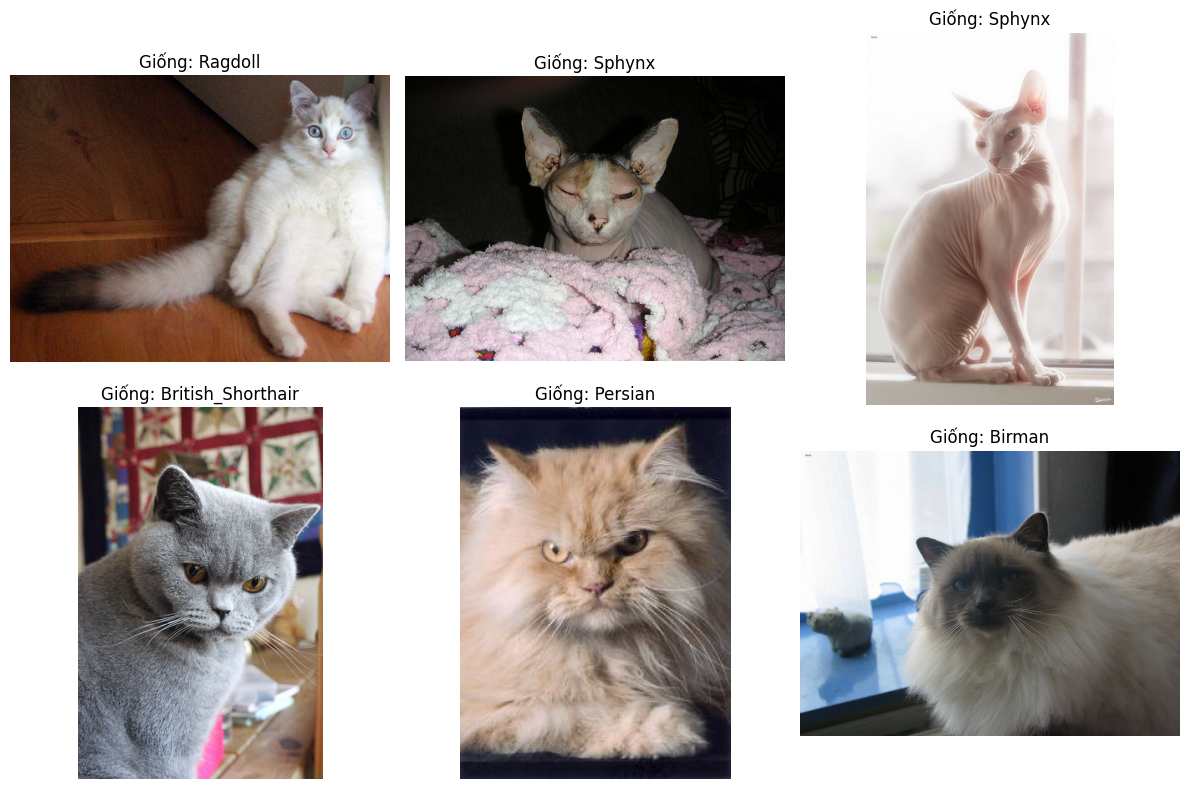

In [11]:
# Hiển thị ngẫu nhiên 6 ảnh mèo trong tập Train kèm tên giống
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
sample_rows = train_df.sample(6, random_state=42)

for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
  breed = row["Breed_Name"]
  img_path = os.path.join(
      PROCESSED_DATA_DIR, "train", breed, f"{row['Image']}.jpg"
  )

  img = Image.open(img_path)
  ax.imshow(img)
  ax.set_title(f"Giống: {breed}")
  ax.axis("off")

plt.tight_layout()
plt.show()
